In [4]:
from obspy import read
import numpy as np
from sklearn.linear_model import Lasso
import os

In [5]:
d25 = set(os.listdir("./Dec25Data/"))
d26 = set(os.listdir("./Dec26Data/"))
d27 = set(os.listdir("./Dec27Data/"))
d28 = set(os.listdir("./Dec28Data/"))
d29 = set(os.listdir("./Dec29Data/"))
d30 = set(os.listdir("./Dec30Data/"))
d31 = set(os.listdir("./Dec31Data/"))

stationsS = d25.intersection(d26,d27,d28,d29,d30,d31)
print(len(stationsS))
print(stationsS)

294
{'BK_WROK', 'CI_LCG', 'CI_SWS', 'CI_CSH', 'CI_CLT', 'PY_BPH06', 'AZ_KNW', 'CI_BAC', 'CI_DTP', 'CI_PEM', 'CI_FMP', 'CI_SWP', 'CI_RMM', 'CI_MTG', 'CI_LMS', 'CI_SBB2', 'CI_JEM', 'CI_PASC', 'CI_PSD', 'CI_BBS', 'CI_CCT', 'CI_HMT2', 'CI_MSC', 'CI_HYS', 'CI_LDF', 'CI_NCH', 'CI_IDO', 'CI_MLS', 'CI_AGM', 'CI_PDR', 'AZ_SND', 'CI_LCP', 'CI_ABL', 'CI_SHU', 'NC_PZO', 'CI_SVD', 'YN_JORD', 'CI_TEJ', 'CI_BEL', 'CI_POP', 'CI_HRV', 'PY_BPH10', 'BC_TJX', 'CI_RIO', 'CI_SRI', 'CI_FHO', 'CI_DRE', 'CI_LGB', 'CI_PZA', 'CI_LMH', 'CI_WGR', 'PB_B082', 'CI_CHL', 'CI_ALP', 'CI_SLH', 'CI_SBC', 'CI_BAK', 'PY_BPH12', 'CI_LMY', 'CI_RUS', 'CI_RAG', 'CI_CTW', 'CI_RXH', 'CI_HEC', 'CI_SOC', 'CI_ESI2', 'CI_DAN', 'CI_JTH', 'CI_IDY', 'CI_BTL2', 'CI_RRX', 'CI_CAR', 'CI_LRL', 'CI_LVY', 'CI_SMR', 'CI_VLY', 'CI_TFT', 'CI_CHN', 'CI_IRM', 'PY_BPH13', 'CI_FIG', 'CI_SRN', 'CI_STC', 'CI_TOR', 'CI_JNH2', 'CI_DEC', 'PY_BPH08', 'CI_TEH', 'CI_BLY', 'CI_FMO', 'CI_RVR', 'CI_SMM', 'CI_BHP', 'CI_SMI', 'CI_CRR', 'CI_SDR', 'CI_DGR', 'CI_PT

In [ ]:
#some of the stations must have downloaded wrong and had more than 200 waves when supposed to have 1
#this finds them

DATA_MAIN = ["DEC25DATA","DEC26DATA","DEC27DATA","DEC28DATA","DEC29DATA","DEC30DATA","DEC31DATA"]
s = set()
for day in DATA_MAIN:
    patterns = ["./" + day + "/" + s + "/*.mseed" for s in stationsS]

    for pattern in patterns:
        st = read(pattern)
        if len(st)!=3:
            s.add(pattern[12:])

print(s)

{'BC_UABX/*.mseed', 'BC_YUC2X/*.mseed', 'BC_TKX/*.mseed', 'BC_TJX/*.mseed', 'CI_PASC/*.mseed', 'BC_JARAX/*.mseed', 'CI_TER2/*.mseed', 'SB_VAFB2/*.mseed', 'CI_SUN/*.mseed'}


In [ ]:
#finding the avg thickness of a function
#found the spread - outliers.
#outliers are user defined in x
#then sorts all of the thickness and chops off the top 100-z percent
#a lot of functions are reaally peaky this gets rid of those

def thickness(y, x, z):
    t = []
    n = y.size//100
    for i in range(100):
        q75, q25 = np.percentile(y[i*n:(i+1)*n], [100-x,x])
        t.append(q75-q25)

    return np.mean(sorted(t)[:n*z])/1000

In [ ]:
DATA_MAIN = ["DEC25DATA","DEC26DATA","DEC27DATA","DEC28DATA","DEC29DATA","DEC30DATA","DEC31DATA"]
slopes = []

for day in DATA_MAIN[1:2]:
    patterns = ["./" + day + "/" + s + "/*.mseed" for s in stationsS]
    patterns.remove("./DEC26DATA/BC_UABX/*.mseed")
    patterns.remove("./DEC26DATA/BC_YUC2X/*.mseed")
    patterns.remove("./DEC26DATA/BC_TKX/*.mseed")
    patterns.remove("./DEC26DATA/BC_TJX/*.mseed")
    patterns.remove("./DEC26DATA/CI_PASC/*.mseed")
    patterns.remove("./DEC26DATA/BC_JARAX/*.mseed")
    patterns.remove("./DEC26DATA/CI_TER2/*.mseed")
    patterns.remove("./DEC26DATA/SB_VAFB2/*.mseed")
    patterns.remove("./DEC26DATA/CI_SUN/*.mseed")

    for pattern in patterns:
        st = read(pattern)
        for tr in st:
            n = tr.data.size//10
            y = np.concatenate([tr.data[:n],tr.data[-n:]]).astype(np.float32)
            X = np.arange(y.size).reshape(-1,1)
            #used Lasso Regression to stabalize line to outliers. Uses median instead of mean
            reg = Lasso()
            reg.fit(X, y)
            #slope/thickness regularizes score
            #if super thick in relation to slope would be relatively flat but still flag. Fixed
            slopes.append((tr.id, abs(reg.coef_[0]/(thickness(y, 25, 50))),tr))

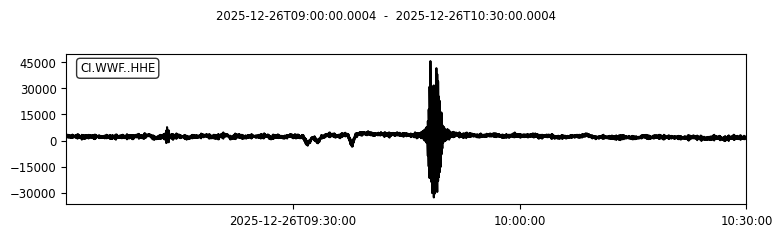

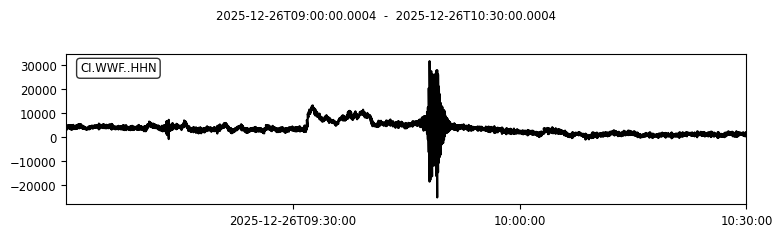

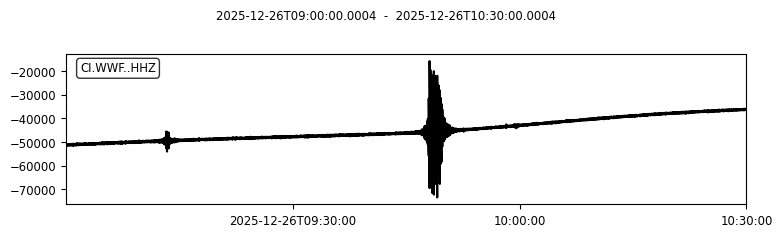

In [15]:
path1 = "./DEC26DATA/CI_WWF/*.mseed"
path2 = "./DEC26DATA/CI_HHZ/*.mseed"

st = read(path1)
for tr in st:
    tr.plot();

0.9317532348384391


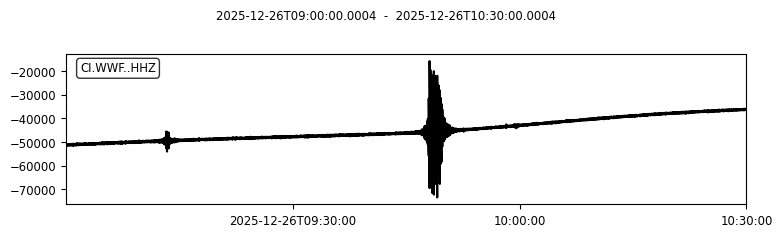

0.8245663016826883


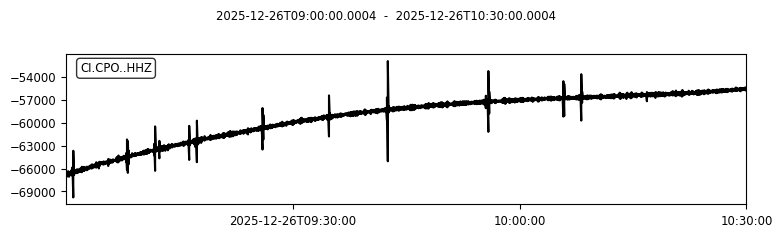

0.3930073949142906


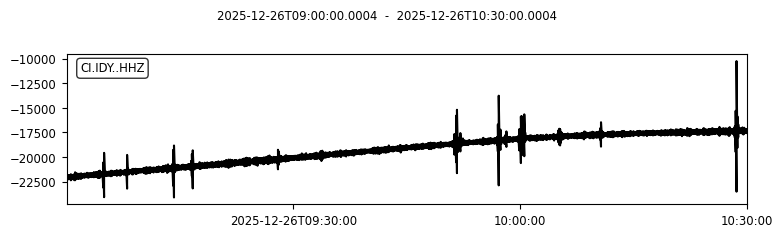

0.3207811824999805


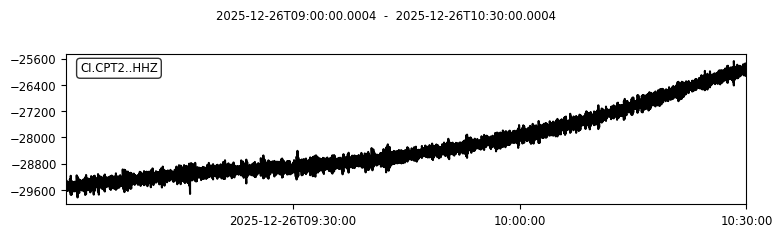

0.23952729277427048


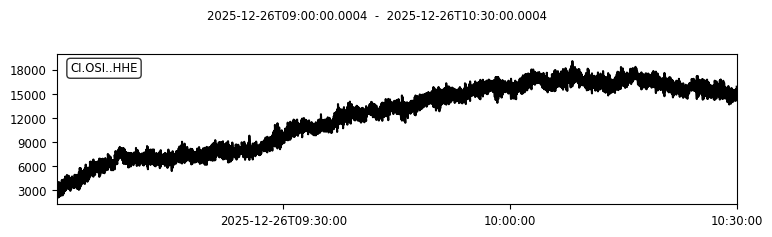

0.2393618465585939


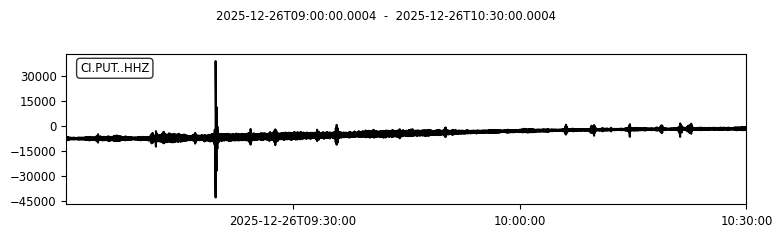

0.22795204802020597


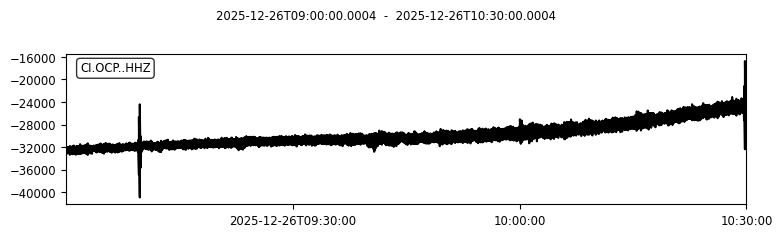

0.22728446364471785


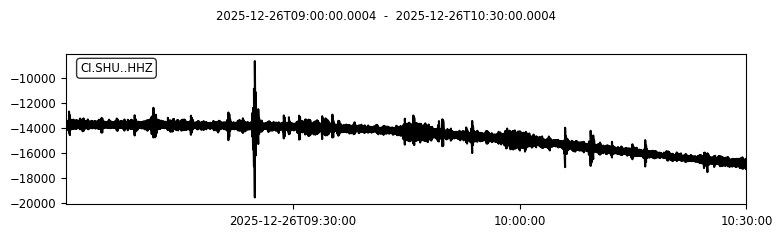

0.22561880354218913


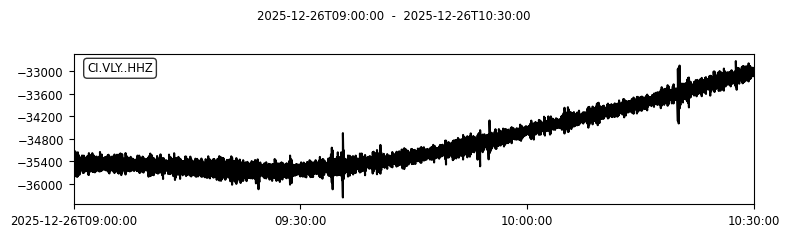

0.22219043786779846


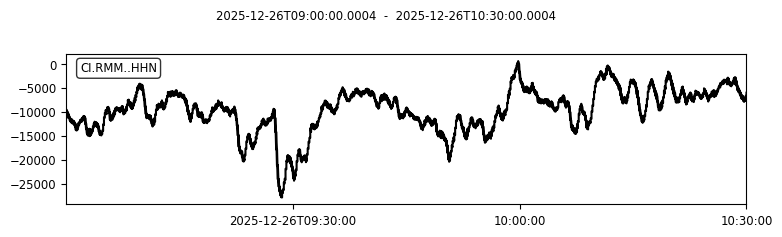

0.17061244261859188


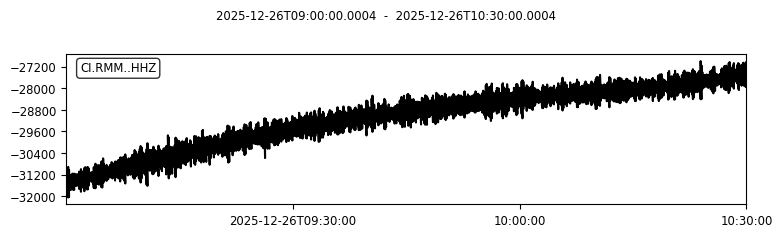

0.16987367091971958


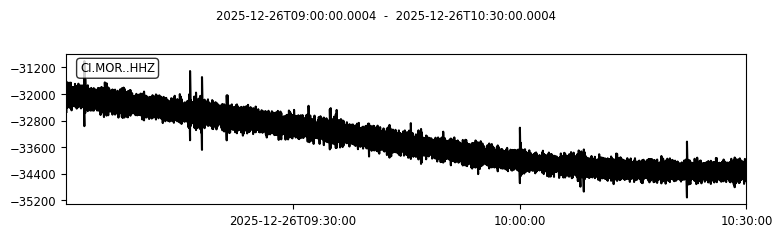

0.1685643361480758


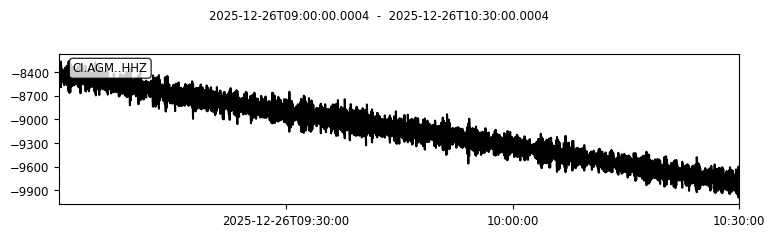

0.16105182312086128


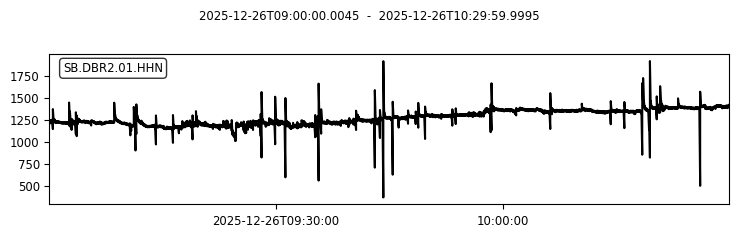

0.15182876262813882


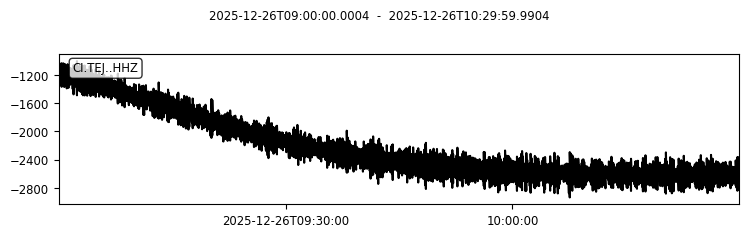

0.14607701693145445


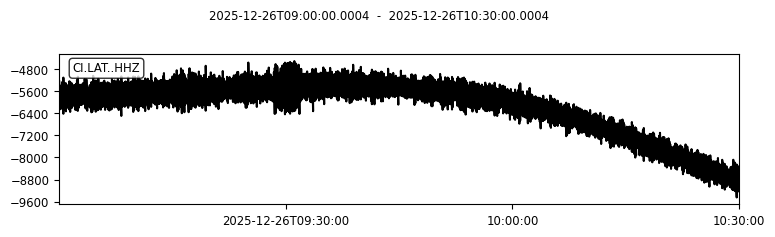

0.1442991866786421


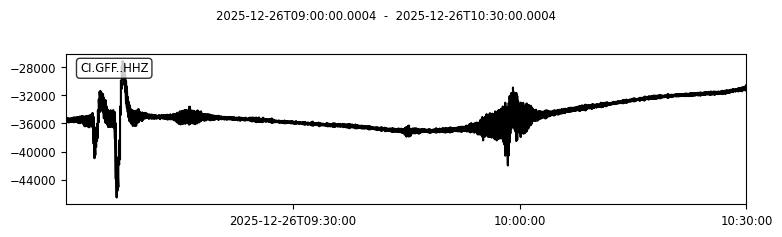

0.11439820421382457


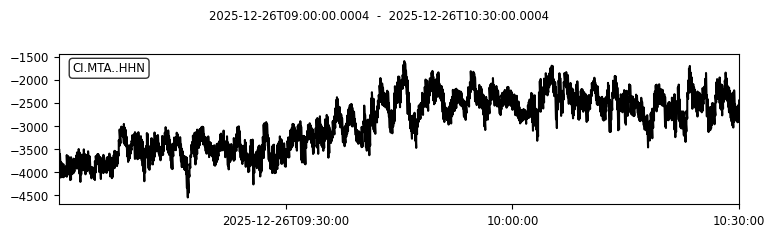

0.10749731788084718


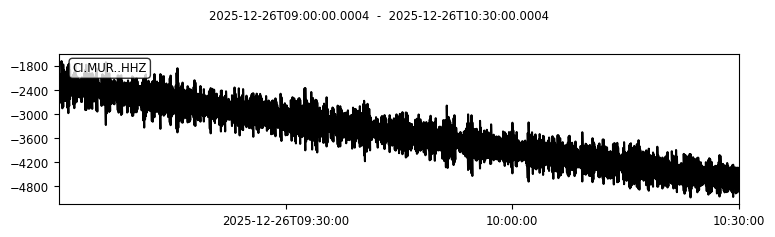

0.10483645988554635


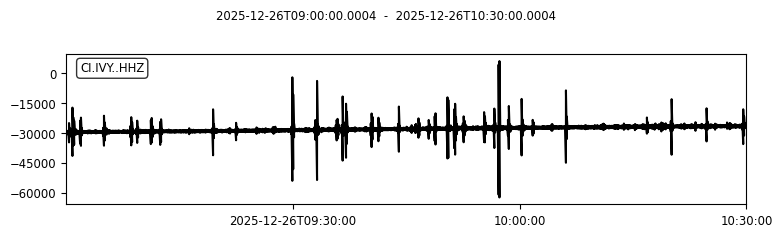

0.10293078121696847


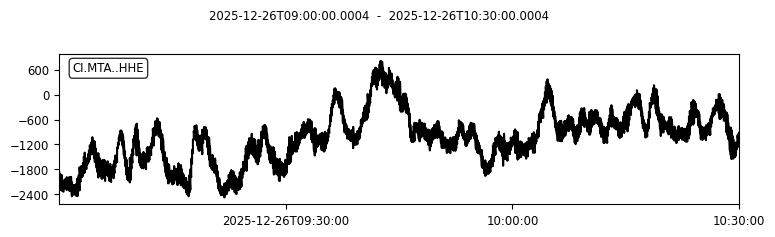

0.10078639833732315


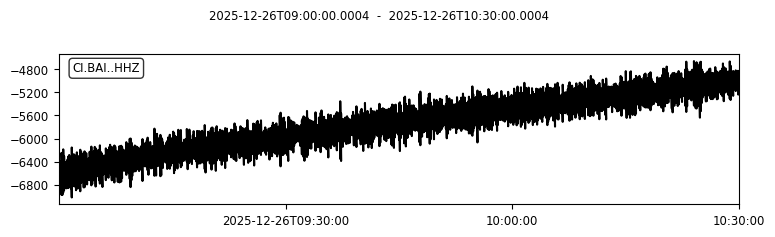

0.09756624422175428


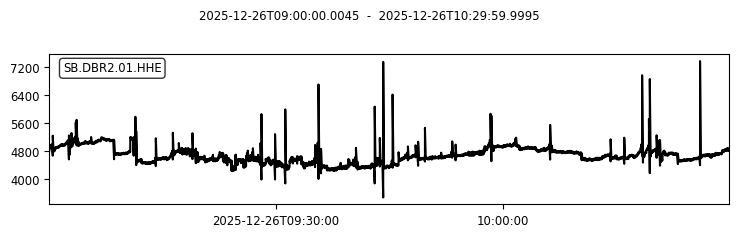

0.0963961530401587


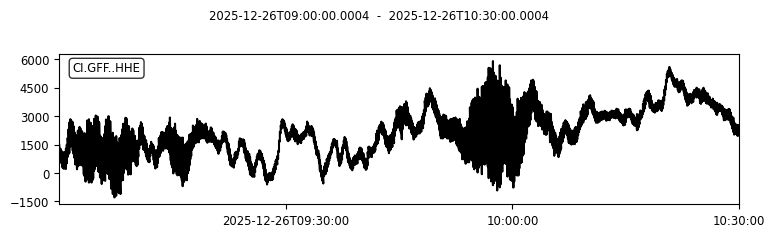

0.08800613143616547


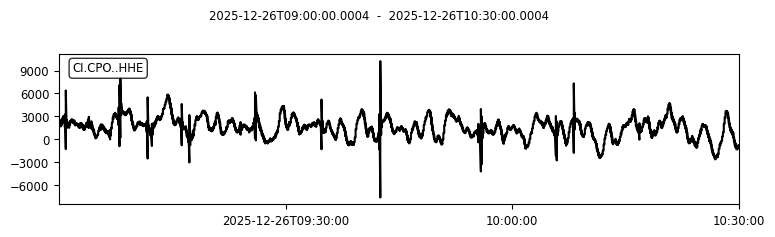

0.07902255026763741


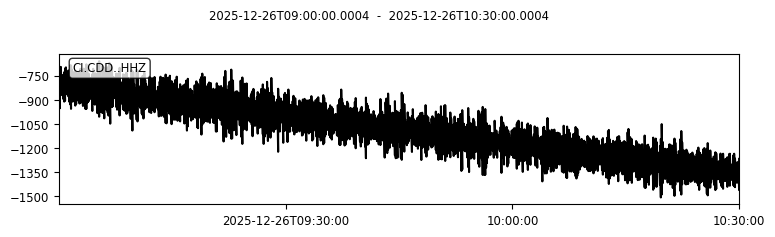

0.07804863825737872


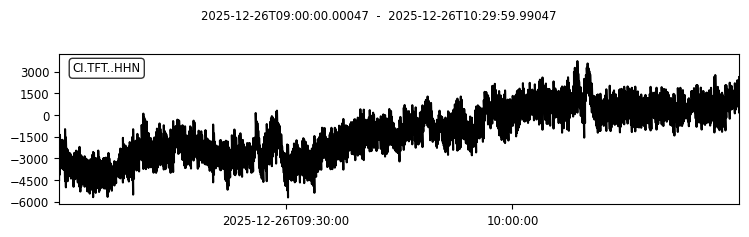

0.07789249585498659


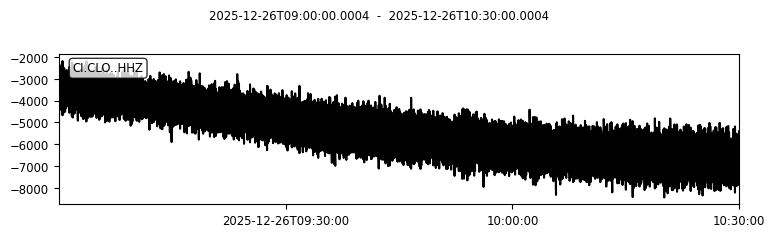

0.07403231650168736


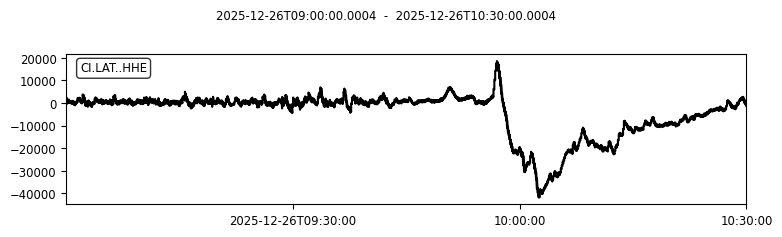

0.07390513975940306


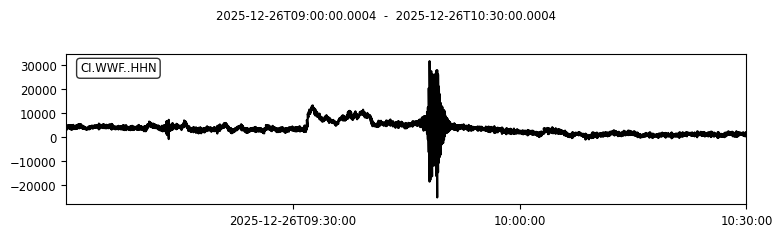

0.06997504579654695


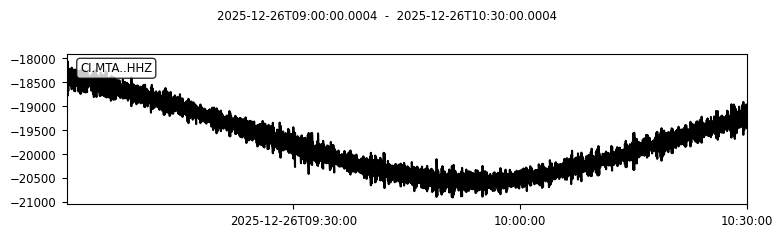

0.06948745273866538


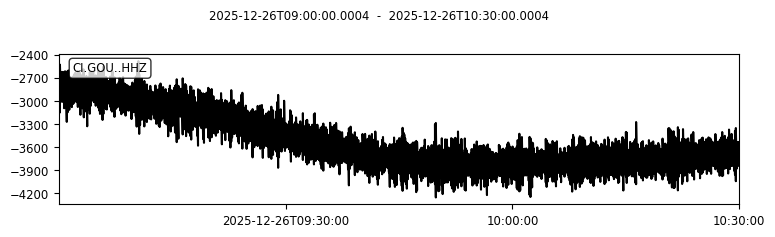

0.06884616060260768


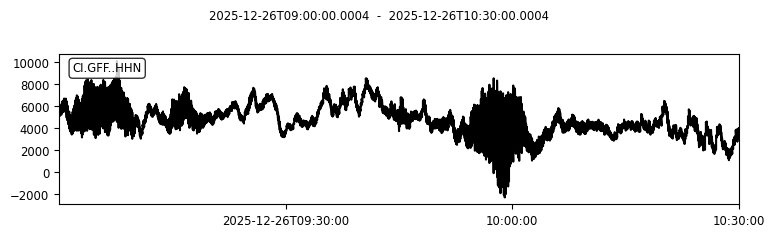

0.06814854315491058


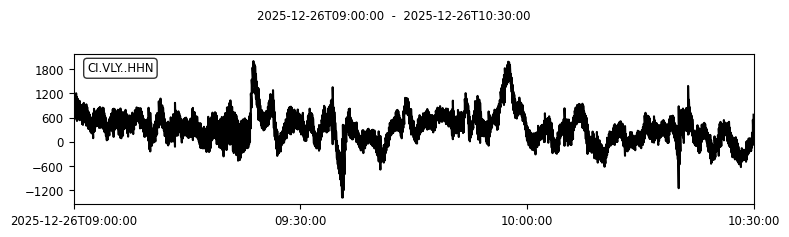

0.06749125903798289


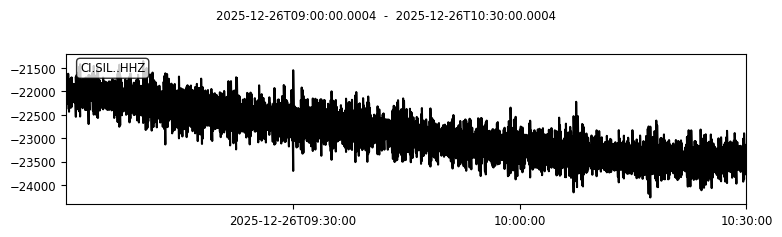

0.06611180493535554


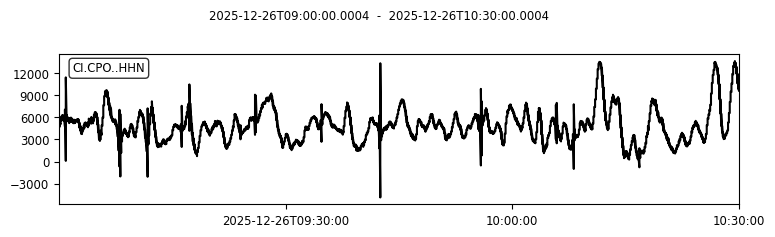

0.062735388810461


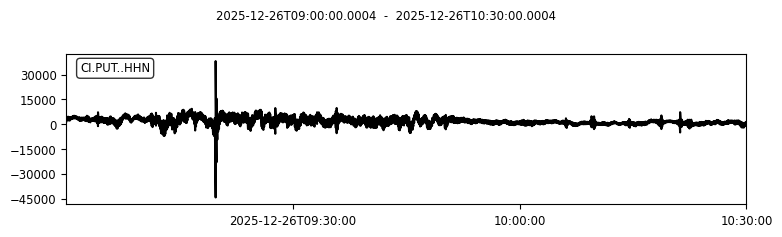

0.06070432646612636


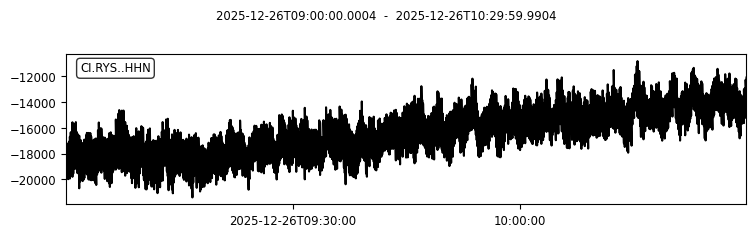

0.05859089009380491


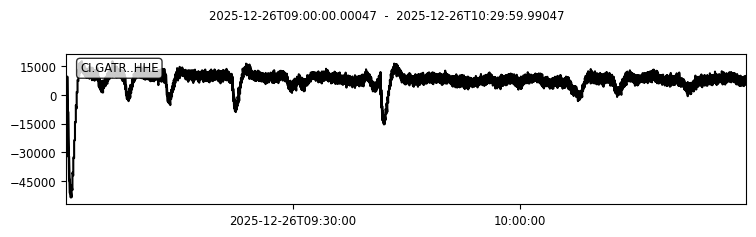

0.05553703798495235


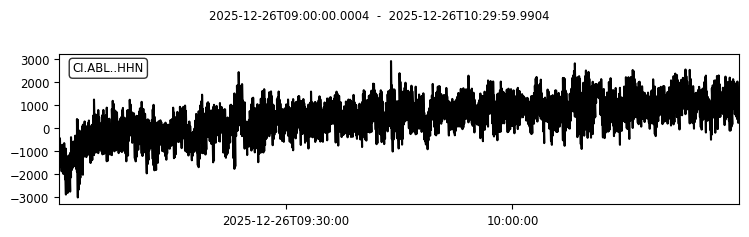

0.05334188401617739


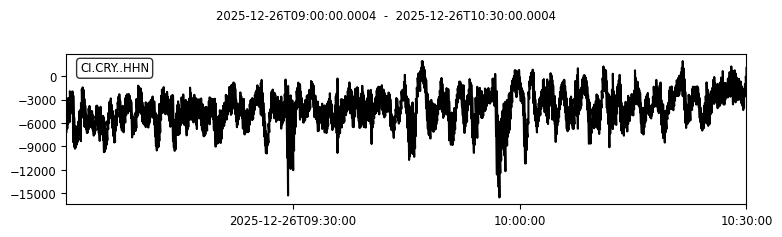

0.052796861471189144


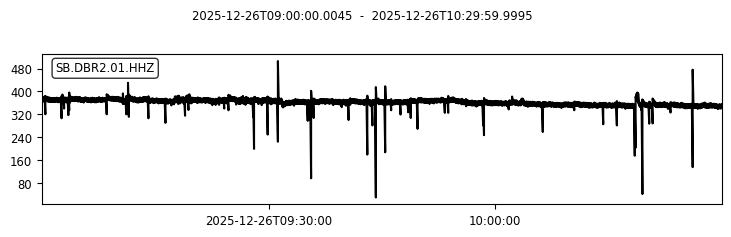

0.050892423917747294


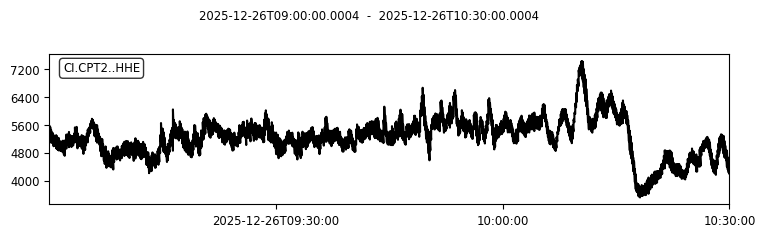

0.0501085808422322


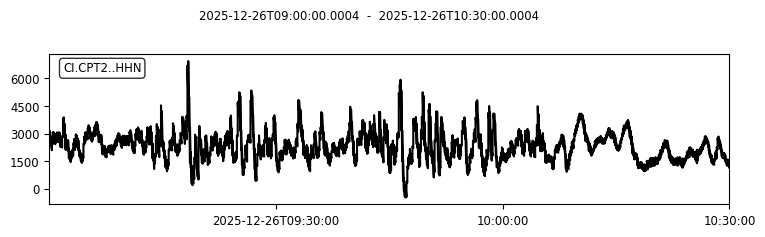

0.04973694011192557


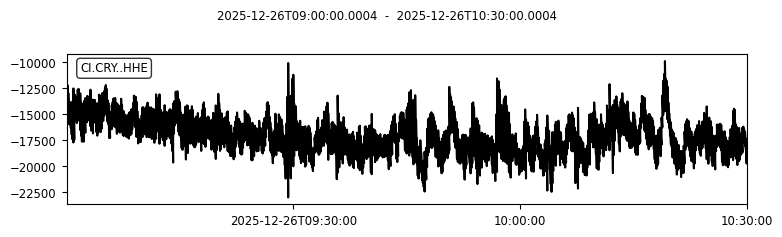

0.04971538711888005


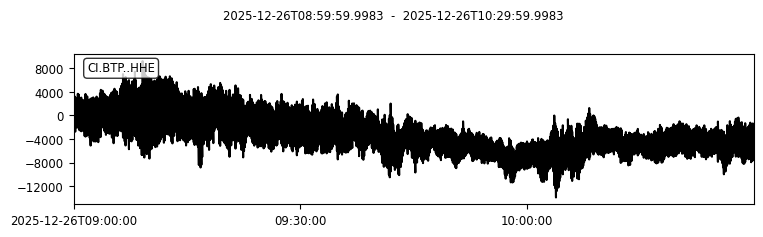

0.04731901219338251


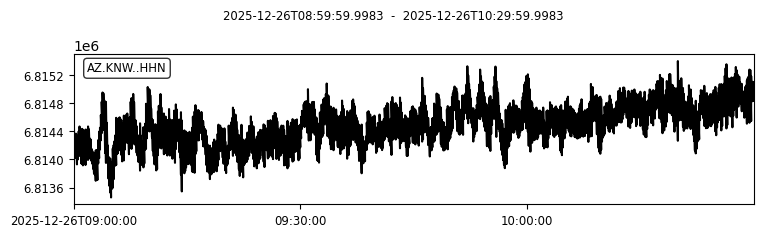

0.041154535658515526


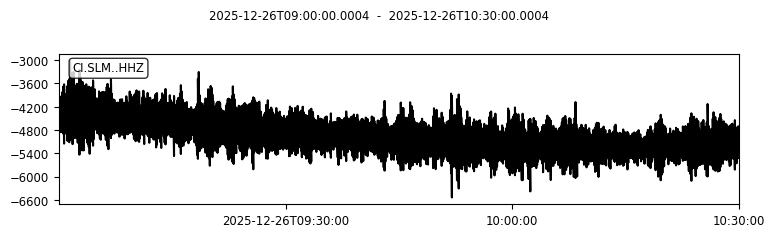

0.041085364069162085


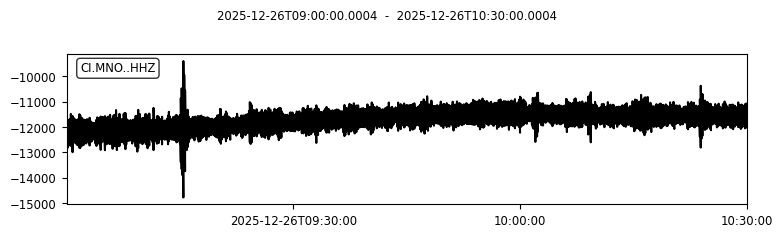

0.03950989362220706


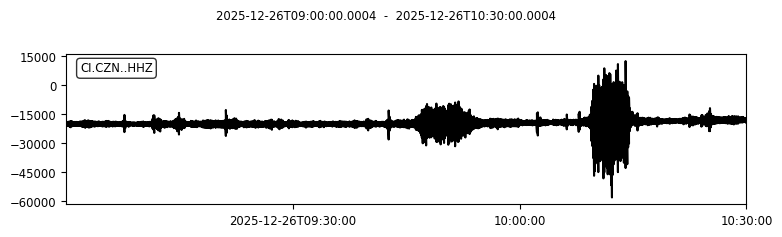

In [ ]:
slopes.sort(reverse=True , key=lambda x:x[1])
for slope in slopes[:50]:
    print(slope[1])
    slope[2].plot();

In [ ]:
# FAS of NWE
# then smooth all. val 40 konno-omachi smoothing
# Geomean 
#window length 180
